In [ ]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
import time
start_time = time.time()


gas_mix_incomplete = ct.Solution('gri30.yaml')

In [ ]:
p = ct.one_atm # atm
phi = 1.4

T_list = np. linspace(300,650,15)


vel_list = []
# Hay que vaciar vel_list al acabar cada bucle de presión
# para no juntar velocidades de todas las phi.
for j, T in enumerate(T_list):
    print(f"\033[1;36m## Temperature (K): {T} ##\033[0m")

    gas_mix_incomplete.set_equivalence_ratio(phi, 'CH4', 'O2: 1.0, N2: 3.76')
    # Restablecer composición a la de los reactantes antes de resolver la llama de nuevo

    gas_mix_incomplete.TP = T, p

    # Llama
    flame = ct.FreeFlame(gas=gas_mix_incomplete, width=0.03)
    flame.set_refine_criteria(ratio=3, slope=0.06, curve=0.12)

    if j != 0:
        flame.set_initial_guess(data=flame_sol_previa)

    flame.solve(loglevel=0, refine_grid=True, auto=True)
    flame_sol_previa = flame.to_array()

    print(f"\033[1;36m# LAMINAR BURNING SPEED (cm/s): {flame.velocity[0]*100} cm/s ###\033[0m")
    vel_list.append(flame.velocity[0] * 100) # cm/s
    # plt.plot(flame.grid, flame.velocity)
    # plt.show()


    print("Run time %s seconds ---" % (time.time() - start_time))

## Temperature (K): 300.0 ##
# LAMINAR BURNING SPEED (cm/s): 14.086183423081167 cm/s ###
Run time 14.129289388656616 seconds ---
## Temperature (K): 325.0 ##
# LAMINAR BURNING SPEED (cm/s): 16.688314787142478 cm/s ###
Run time 19.249487161636353 seconds ---
## Temperature (K): 350.0 ##
# LAMINAR BURNING SPEED (cm/s): 19.62939013105432 cm/s ###
Run time 23.0694899559021 seconds ---
## Temperature (K): 375.0 ##
# LAMINAR BURNING SPEED (cm/s): 22.96953528609401 cm/s ###
Run time 25.741371154785156 seconds ---
## Temperature (K): 400.0 ##
# LAMINAR BURNING SPEED (cm/s): 26.68695257948724 cm/s ###
Run time 28.632816553115845 seconds ---
## Temperature (K): 425.0 ##
# LAMINAR BURNING SPEED (cm/s): 30.82673905537171 cm/s ###
Run time 31.18979501724243 seconds ---
## Temperature (K): 450.0 ##
# LAMINAR BURNING SPEED (cm/s): 35.377222328863084 cm/s ###
Run time 33.713141202926636 seconds ---
## Temperature (K): 475.0 ##
# LAMINAR BURNING SPEED (cm/s): 40.323063225840336 cm/s ###
Run time 36.276

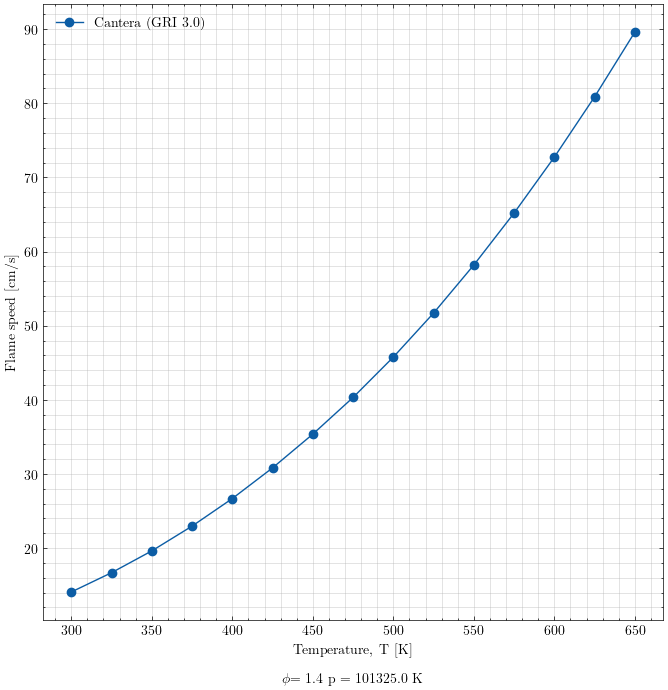

Complete run time --- 60.63577198982239 seconds ---


In [ ]:
plt.figure(figsize=(8,8))
plt.plot(T_list,
        vel_list,
        label="Cantera (GRI 3.0)",
        marker="o")
plt.grid(True, which='both', alpha=0.5)
plt.xlabel("Temperature, T [K] \n \n" + r"$\phi$" + f"= {phi}    p = {p} K")
plt.ylabel("Flame speed [cm/s]")
plt.legend(loc='best', fontsize=10)
plt.savefig("S_vs_T.svg")
plt.show()

print("Complete run time --- %s seconds ---" % (time.time() - start_time))